In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
%matplotlib inline
from matplotlib import pyplot as plt
from matplotlib import style

# Algorithms
from sklearn import linear_model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

import plotly.express as px
import plotly.graph_objects as go
import plotly.subplots as make_subplots

# Reading the dataset

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/gender_submission.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/train.csv


In [3]:
train_df = pd.read_csv('/kaggle/input/titanic/train.csv')
test_df = pd.read_csv('/kaggle/input/titanic/test.csv')

In [4]:
train_df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [5]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

There are 177 empty rows in 'Age' column, 687 empty rows in 'Cabin' column and 2 empty rows in Embarked column of training dataset

In [6]:
test_df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

There are 86 missing rows in 'Age', 327 rows in 'Column' and 1 row in 'Fare' column of test dataset

In [7]:
df = pd.concat([train_df, test_df], axis = 0, sort = False)

In [8]:
print(f'Combined shape = {df.shape}')
print(f'Test shape = {test_df.shape}')
print(f'Train shape = {train_df.shape}')

Combined shape = (1309, 12)
Test shape = (418, 11)
Train shape = (891, 12)


In [9]:
df = df.reset_index()

In [10]:
df.drop(columns = ['index'], inplace = True)

# Cleaning

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


In [12]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


In [13]:
null_cols = df.isnull().sum()
null_cols = pd.DataFrame(null_cols)
null_cols = null_cols.reset_index()
null_cols = null_cols.rename(columns = {'index' : 'Features', 0 : '# of Missing Values'})
null_cols

,Features,# of Missing Values
0,PassengerId,0
1,Survived,418
2,Pclass,0
3,Name,0
4,Sex,0
5,Age,263
6,SibSp,0
7,Parch,0
8,Ticket,0
9,Fare,1


In [14]:
fig = px.bar(null_cols, 
            x = 'Features',
            y = '# of Missing Values',
            hover_data = ['# of Missing Values'],
            color = 'Features',
            title = 'Missing values in columns')
fig.show()

In [15]:
Sex = pd.DataFrame(df['Sex'].value_counts())
Sex = Sex.reset_index().rename(columns = {'index' : 'Gender', 'Sex' : 'Count'})
fig = px.pie(Sex,
            values = 'Count',
            names = 'Gender',
            title = '# of Male and Female in dataset')
fig.show()

In [16]:
Embarked = pd.DataFrame(df['Embarked'].value_counts())
Embarked = Embarked.reset_index().rename(columns = {'index' : 'Embarked', 'Embarked' : 'Count'})
fig = px.pie(Embarked,
            values = 'Count',
            names = 'Embarked',
            title = 'Embarkment')
fig.show()

In [17]:
PassengerClass = pd.DataFrame(df['Pclass'].value_counts())
PassengerClass = PassengerClass.reset_index().rename(columns = {'index' : 'Pclass', 'Pclass' : 'Count'})
fig = px.pie(PassengerClass,
            values = 'Count',
            names = 'Pclass',
            title = '# of passengers in different class')
fig.show()

Replacing the age value in the test and train dataset with the median value of the age column in their respective dataset

In [18]:
df['Age'].fillna(df.groupby("Pclass")["Age"].transform(lambda x: x.fillna(x.median())), inplace = True)
df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

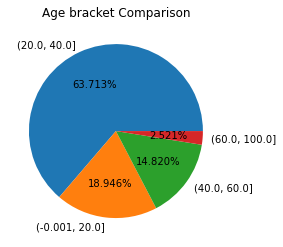

In [19]:
P = pd.DataFrame()
P['age_range'] = pd.cut(df['Age'], [0,20,40,60,100], include_lowest=True)
AgeRange = pd.DataFrame(P['age_range'].value_counts())
AgeRange = AgeRange.reset_index().rename(columns = {'index' : 'Range', 'age_range' : 'Count'})
plt.pie(AgeRange['Count'],
       labels=AgeRange['Range'],
       autopct='%.3f%%')
plt.title('Age bracket Comparison')
plt.show()

Replacing the embarked column with the most frequently occuring value in the Embarked column since there are a really few na present

In [20]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace = True)
df.isna().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          0
dtype: int64

Replacing the fare column in the test dataset with the median value of the column

In [21]:
df['Fare'].fillna(df.groupby("Pclass")["Fare"].transform(lambda x: x.fillna(x.median())), inplace = True)
df.isnull().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          0
dtype: int64

Cabin column is dropped because there are a lot of na present in them

In [22]:
df.drop(columns = ['Cabin'], inplace = True)

In [23]:
df.isnull().sum()

PassengerId      0
Survived       418
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64

In [24]:
Classwise_Embarkment = pd.DataFrame(df[['PassengerId','Pclass', 'Embarked']].groupby(['Pclass','Embarked']).count())
Classwise_Embarkment

PassengerId
Pclass Embarked             
1      C                 141
       Q                   3
       S                 179
2      C                  28
       Q                   7
       S                 242
3      C                 101
       Q                 113
       S                 495

Out of all the passengers who boarded first class, 141 embarked from C, only 3 from Q while 179 embarked from S

28 of the total passengers from second class embarked from C. 7 embarked from Q while 242 embarked by S

101 passengers from third class embarked from C, 113 embarked from Q while 495 embarked from S

In [25]:
ClasswiseGender=pd.DataFrame(df[['Pclass', 'PassengerId', 'Sex']].groupby(['Pclass', 'Sex']).count()).rename(columns = {'PassengerId' : 'Count'})
ClasswiseGender

Count
Pclass Sex          
1      female    144
       male      179
2      female    106
       male      171
3      female    216
       male      493

In [26]:
df.drop(columns = ['Ticket'], inplace = True)


In [27]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand = False)
df['Title'].value_counts()

Mr          757
Miss        260
Mrs         197
Master       61
Dr            8
Rev           8
Col           4
Mlle          2
Ms            2
Major         2
Sir           1
Mme           1
Capt          1
Don           1
Dona          1
Countess      1
Lady          1
Jonkheer      1
Name: Title, dtype: int64

In [28]:
title_list = list(df['Title'].unique())
list_rare = ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
for title in df['Title']:
    df['Title'] = df['Title'].replace(list_rare, 'Rare')
    df['Title'] = df['Title'].replace('Mlle', 'Miss')
    df['Title'] = df['Title'].replace('Ms', 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')
    df['Title'] = df['Title'].replace('Miss', 'Miss')
    df['Title'] = df['Title'].replace('Mrs', 'Mrs')
    df['Title'] = df['Title'].replace('Mr', 'Mr')
    df['Title'] = df['Title'].replace('Master', 'Master')
df['Title'].value_counts()

Mr        757
Miss      264
Mrs       198
Master     61
Rare       29
Name: Title, dtype: int64

In [29]:
df['Accompany'] = df['SibSp']+df['Parch']

In [30]:
df[['Pclass', 'Accompany', 'PassengerId']].groupby(['Pclass', 'Accompany']).count()

PassengerId
Pclass Accompany             
1      0                  160
       1                  104
       2                   39
       3                    9
       4                    5
       5                    6
2      0                  158
       1                   52
       2                   45
       3                   20
       4                    1
       5                    1
3      0                  472
       1                   79
       2                   75
       3                   14
       4                   16
       5                   18
       6                   16
       7                    8
       10                  11

In [31]:
df.drop(columns = ['Name', 'SibSp', 'Parch'], inplace = True)
df.reset_index(inplace = True)

In [32]:
gender_survival = df[['Sex', 'Survived']].groupby('Survived').count()
gender_survival = gender_survival.reset_index().rename(columns = {'index' : 'Survived'})
gender_survival

,Survived,Sex
0,0.0,549
1,1.0,342


In [33]:
labels = ['Female', 'Male']
fig = px.pie(gender_survival,
            values = 'Sex',
            names = labels,
            title = 'Genderwise chance of Survival')
fig.show()

In [34]:
Classwise_survival = df[['Pclass', 'Survived', 'PassengerId']].groupby(['Pclass', 'Survived']).count()
Classwise_survival = Classwise_survival.reset_index().rename(columns = {'index' : 'Pclass'})
Classwise_survival

,Pclass,Survived,PassengerId
0,1,0.0,80
1,1,1.0,136
2,2,0.0,97
3,2,1.0,87
4,3,0.0,372
5,3,1.0,119


In [35]:
Class1 = Classwise_survival[Classwise_survival['Pclass'] == 1]
Class2 = Classwise_survival[Classwise_survival['Pclass'] == 2]
Class3 = Classwise_survival[Classwise_survival['Pclass'] == 3]
fig = go.Figure(data=[
    go.Bar(name='Pclass1', x=Class1['Survived'], y=Class1['PassengerId']),
    go.Bar(name='Pclass2', x=Class2['Survived'], y=Class2['PassengerId']),
    go.Bar(name='Pclass3', x=Class3['Survived'], y=Class3['PassengerId'])
])
# Change the bar mode
fig.update_layout(barmode='group', title = 'Classwise Chance of survival')
fig.show()

In above plot, 1 on x-axis indicates survival whereas 0 indicates not survived. As it's visible from the plot above, Passengers of firstclass are more likely to survive than anyone else while passengers of class 3 are least likely to survive.

In [36]:
Embarked = pd.DataFrame(df['Embarked'].value_counts())
Embarked.reset_index().rename(columns = {'index' : 'E'})

,E,Embarked
0,S,916
1,C,270
2,Q,123


In [37]:
# from sklearn.preprocessing import LabelEncoder
# df['Sex'] = LabelEncoder().fit_transform(df['Sex'])
# df['Sex'].value_counts()
# df.head()
from sklearn.preprocessing import OneHotEncoder
onehotencoder = OneHotEncoder() 
data = pd.DataFrame(onehotencoder.fit_transform(df[['Sex']]).toarray())
data = data.reset_index()
df = pd.merge(left = df, right = data, on = 'index')
#test_df.rename(columns = {0:'Master', 1:'Miss', 2:'Mr', 3:'Mrs', 4:'Rare'}, inplace = True)
df = df.drop(columns = ['Sex'])
df.sort_values(by = 'PassengerId', inplace = True)

In [38]:
df.rename(columns = {0:'Female', 1:'Male'}, inplace= True)

In [39]:
from sklearn.preprocessing import OneHotEncoder
onehotencoder = OneHotEncoder() 
data = pd.DataFrame(onehotencoder.fit_transform(df[['Embarked']]).toarray())
data = data.reset_index()
df = pd.merge(left = df, right = data, on = 'index')
df.rename(columns = {0 : 'C', 1 : 'Q', 2 : 'S'}, inplace = True)
df.drop(columns = 'Embarked', inplace = True)

In [40]:
onehotencoder = OneHotEncoder() 
data = pd.DataFrame(onehotencoder.fit_transform(df[['Title']]).toarray())
data = data.reset_index()
df = pd.merge(left = df, right = data)
df.rename(columns = {0:'Master', 1:'Miss', 2:'Mr', 3:'Mrs', 4:'Rare'}, inplace = True)
df = df.sort_values(by = 'PassengerId', ascending = True)

In [41]:
df.drop(columns = 'Title', inplace = True)

In [42]:
df['Fare'] = np.log1p(df['Fare'])

In [43]:
# from sklearn.feature_selection import SelectKBest, f_classif

# predictors = ["Pclass", "Sex", "Age", "Fare", "Embarked", "Title", "Accompany"]

# # Perform feature selection
# selector = SelectKBest(f_classif, k=5)
# selector.fit(train_df[predictors], train_df["Survived"])

# # Get the raw p-values for each feature, and transform from p-values into scores
# scores = -np.log10(selector.pvalues_)

# # Plot the scores.  See how "Pclass", "Sex", "Title", and "Fare" are the best?
# plt.bar(range(len(predictors)), scores)
# plt.xticks(range(len(predictors)), predictors, rotation='vertical')
# plt.show()

In [44]:
df.drop(columns = ['index'], inplace = True)

In [45]:
df['Age'] = pd.cut(df['Age'], 5)

In [46]:
from sklearn.preprocessing import LabelEncoder
df['Age'] = LabelEncoder().fit_transform(df['Age'])
df['Age'].value_counts()

1    748
2    308
0    134
3    106
4     13
Name: Age, dtype: int64

In [47]:
test_df = df[df['PassengerId'] > 891]
test_df.shape

(418, 16)

In [48]:
train_df = df[df['PassengerId'] <= 891]
train_df.shape

(891, 16)

In [49]:
test_df.isnull().sum()

PassengerId      0
Survived       418
Pclass           0
Age              0
Fare             0
Accompany        0
Female           0
Male             0
C                0
Q                0
S                0
Master           0
Miss             0
Mr               0
Mrs              0
Rare             0
dtype: int64

In [50]:
test_df.drop(columns = ['Survived'], inplace = True)

In [51]:
passenger_id = test_df['PassengerId']
test_df.drop(columns = ['PassengerId'], inplace = True)

In [52]:
test_df.isnull().sum()

Pclass       0
Age          0
Fare         0
Accompany    0
Female       0
Male         0
C            0
Q            0
S            0
Master       0
Miss         0
Mr           0
Mrs          0
Rare         0
dtype: int64

In [53]:
x_train = train_df.drop(columns = 'Survived')
y_train = train_df['Survived']
x_train.drop(columns = ['PassengerId'], inplace = True)

In [54]:
y_train = pd.DataFrame(y_train)

In [55]:
y_train = y_train['Survived'].astype(int)

# Prediction

### Logistic Regression

In [56]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(x_train, y_train)
y_pred = logreg.predict(test_df)
acc_log = round(logreg.score(x_train, y_train) * 100, 2)
acc_log

83.05

In [57]:
from sklearn.model_selection import GridSearchCV
clf = LogisticRegression()
grid_values = {'penalty': ['l1', 'l2'],
               'C':[1,3,5,7,10,11,12]
              }
grid = GridSearchCV(clf, param_grid = grid_values,scoring = 'recall', cv = 5)
grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [1, 3, 5, 7, 10, 11, 12],
                         'penalty': ['l1', 'l2']},
             scoring='recall')

In [58]:
grid.best_params_

{'C': 3, 'penalty': 'l2'}

In [59]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(C= 3, penalty= 'l2')
logreg.fit(x_train, y_train)
y_pred = logreg.predict(test_df)
acc_log = round(logreg.score(x_train, y_train) * 100, 2)
acc_log

82.94

In [60]:
# from sklearn.model_selection import cross_val_score
# clf = LogisticRegression(C= 10, penalty= 'l1', solver= 'liblinear')
# scores = cross_val_score(clf, x_train, y_train, cv=5)
# scores = scores.mean()
# scores

In [61]:
from sklearn.model_selection import cross_val_score
clf = LogisticRegression(C= 3, penalty= 'l2')
scores = cross_val_score(clf, x_train, y_train, cv=5)
scores = scores.mean()
scores

0.822666499278137

### Support Vector Machine

In [62]:
# Support Vector Machines
svc = SVC(C= 3, gamma= 0.06, kernel= 'linear')
svc.fit(x_train, y_train)
Y_pred = svc.predict(test_df)
acc_svc = round(svc.score(x_train, y_train) * 100, 2)
acc_svc

83.05

In [63]:
# from sklearn.model_selection import GridSearchCV 
# param_grid = {'C': [1, 3, 5, 7, 9], 
#               'gamma': [0.06, 0.08, 0.1, 0.12, 0.14], 
#               'kernel': ['rbf']}  
  
# grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3) 
  
# # fitting the model for grid search 
# grid.fit(x_train, y_train) 

In [64]:
# grid.best_params_

In [65]:
# from sklearn.model_selection import cross_val_score
# clf = SVC(C= 2, gamma = 1, kernel= 'linear')
# scores = cross_val_score(clf, x_train, y_train, cv=5)
# scores = scores.mean()
# scores

In [66]:
from sklearn.model_selection import cross_val_score
clf = SVC(C= 3, gamma= 0.06, kernel= 'linear')
scores = cross_val_score(clf, x_train, y_train, cv=5)
scores = scores.mean()
scores

0.8293829640323895

### k-Nearest Neighbour

In [67]:
# knn = KNeighborsClassifier(n_neighbors = 3)
# knn.fit(x_train, y_train)
# Y_pred = knn.predict(test_df)
# acc_knn = round(knn.score(x_train, y_train) * 100, 2)
# acc_knn

In [68]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.neighbors import KNeighborsClassifier
# #making the instance
# model = KNeighborsClassifier(n_jobs=-1)
# #Hyper Parameters Set
# params = {'n_neighbors':[3,4,5,6,7,8,9,10],
#           'leaf_size':[10,20,30,40,50,60],
#           'weights':['uniform', 'distance'],
#           'algorithm':['auto', 'ball_tree','kd_tree','brute'],
#           'n_jobs':[-1]}
# #Making models with hyper parameters sets
# model1 = GridSearchCV(model, param_grid=params, n_jobs=1)
# #Learning
# model1.fit(x_train,y_train)

In [69]:
# model1.best_params_

In [70]:
knn = KNeighborsClassifier(algorithm = 'auto', leaf_size = 40, n_neighbors = 7, weights = 'uniform')
knn.fit(x_train, y_train)
Y_pred = knn.predict(test_df)
acc_knn = round(knn.score(x_train, y_train) * 100, 2)
acc_knn

85.3

In [71]:
# from sklearn.model_selection import cross_val_score
# clf = KNeighborsClassifier()
# scores = cross_val_score(clf, x_train, y_train, cv=5)
# scores = scores.mean()
# scores

In [72]:
from sklearn.model_selection import cross_val_score
clf = KNeighborsClassifier(algorithm = 'auto', leaf_size = 40, n_neighbors = 7, weights = 'uniform')
scores = cross_val_score(clf, x_train, y_train, cv=5)
scores = scores.mean()
scores

0.824913690289373

### Gaussian Naive Bayes

In [73]:
# Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB
gaussian = GaussianNB()
gaussian.fit(x_train, y_train)
Y_pred = gaussian.predict(test_df)
acc_gaussian = round(gaussian.score(x_train, y_train) * 100, 2)
acc_gaussian

80.36

In [74]:
from sklearn.model_selection import cross_val_score
clf = GaussianNB()
scores = cross_val_score(clf, x_train, y_train, cv=5)
scores = scores.mean()
scores

0.7979850605737242

### Decision Tree Classifier

In [75]:
# decision_tree = DecisionTreeClassifier()
# decision_tree.fit(x_train, y_train)
# Y_pred = decision_tree.predict(test_df)
# acc_decision_tree = round(decision_tree.score(x_train, y_train) * 100, 2)
# acc_decision_tree

In [76]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.tree import DecisionTreeClassifier
# #making the instance
# model= DecisionTreeClassifier(random_state=0)
# #Hyper Parameters Set
# params = {
#           'max_features': ['auto', 'sqrt', 'log2'],
#           'min_samples_split': [10,15,20,25,30,35,40,45,50,55,60,65,70], 
#           'min_samples_leaf':[1,2,3,4,5,6,7,8,9,10,11],
#           }

# model1 = GridSearchCV(model, param_grid=params, n_jobs=-1)
# #Learning
# model1.fit(x_train,y_train)

In [77]:
# model1.best_params_

In [78]:
decision_tree = DecisionTreeClassifier(max_features= 'auto', min_samples_leaf= 2, min_samples_split= 20)
decision_tree.fit(x_train, y_train)
Y_pred = decision_tree.predict(test_df)
acc_decision_tree = round(decision_tree.score(x_train, y_train) * 100, 2)
acc_decision_tree

85.75

In [79]:
from sklearn.model_selection import cross_val_score
clf = DecisionTreeClassifier(max_features= 'auto', min_samples_leaf= 2, min_samples_split= 20)
scores = cross_val_score(clf, x_train, y_train, cv=5)
scores = scores.mean()
scores

0.8013684012303056

In [80]:
from sklearn.model_selection import cross_val_score
clf = DecisionTreeClassifier(max_features= 'auto', min_samples_leaf= 2, min_samples_split= 20)
scores = cross_val_score(clf, x_train, y_train, cv=5)
scores = scores.mean()
scores

0.7901575544535812

### RandomForestClassifier

In [81]:
# random_forest = RandomForestClassifier(n_estimators=100)
# random_forest.fit(x_train, y_train)
# Y_pred = random_forest.predict(test_df)
# random_forest.score(x_train, y_train)
# acc_random_forest = round(random_forest.score(x_train, y_train) * 100, 2)
# acc_random_forest

In [82]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.ensemble import RandomForestClassifier
# #making the instance
# model=RandomForestClassifier()
# #hyper parameters set
# params = {'criterion':['gini','entropy'],
#           'n_estimators':[11,13,15,17,19,21],
#           'min_samples_leaf':[1,2,3,4,5,6],
#           'min_samples_split':[2,3,4,5,6],
#           'n_jobs':[-1]}
# #Making models with hyper parameters sets
# model1 = GridSearchCV(model, param_grid=params, n_jobs=-1)
# #learning
# model1.fit(x_train,y_train)

In [83]:
# model1.best_params_

In [84]:
random_forest = RandomForestClassifier(criterion= 'gini',
                                       min_samples_leaf= 6,
                                       min_samples_split= 6,
                                       n_estimators= 21,
                                       n_jobs= -1)
random_forest.fit(x_train, y_train)
Y_pred = random_forest.predict(test_df)
random_forest.score(x_train, y_train)
acc_random_forest = round(random_forest.score(x_train, y_train) * 100, 2)
acc_random_forest

85.3

In [85]:
from sklearn.model_selection import cross_val_score
clf = RandomForestClassifier(criterion= 'gini',
                            min_samples_leaf= 6,
                            min_samples_split= 6,
                            n_estimators= 21,
                            n_jobs= -1)
scores = cross_val_score(clf, x_train, y_train, cv=5)
scores = scores.mean()
scores

0.8193208210407382

In [86]:
# from sklearn.model_selection import cross_val_score
# clf = RandomForestClassifier(n_estimators=100)
# scores = cross_val_score(clf, x_train, y_train, cv=5)
# scores = scores.mean()
# scores

## Voting

In [87]:
from sklearn.ensemble import VotingClassifier
ensemble=VotingClassifier(estimators=[('Decision Tree', decision_tree), 
                                      ('Random Forest', random_forest), 
                                      ('KNN', knn), 
                                      ('SVC', svc), 
                                      ('Logistic Regression', logreg)], 
                                      voting='soft', 
                                      weights=[1,1,2,1,1]).fit(x_train,y_train)
scores = cross_val_score(clf, x_train, y_train, cv=10)
acc_voting = scores.mean()*100
acc_voting


# from mlxtend.classifier import StackingClassifier
# clf = StackingClassifier(classifiers=[random_forest, decision_tree, knn, svc, logreg], 
#                           meta_classifier=logreg)
# scores = cross_val_score(clf, x_train, y_train, cv=10)
# acc_stacking = scores.mean()*100
# acc_stacking
# #, gaussian



# # for clf, label in zip([random_forest, decision_tree, gaussian, knn, svc, logreg], ['Random Forest', 'Decision Tree', 'GaussianNB', 'KNN', 'SVC', 'Logistic Regression']):
# #     scores = cross_val_score(clf, x_train, y_train, cv=10, scoring='accuracy')
# #     print("Accuracy: %0.2f (+/- %0.2f) [%s]" % (scores.mean(), scores.std(), label))

83.84019975031211

# Model Evaluation

In [88]:
models = pd.DataFrame({
    'Model': ['Support Vector Machines', 'KNN', 'Logistic Regression', 
              'Random Forest', 'Naive Bayes',
              'Decision Tree'],
    'Score': [acc_svc, acc_knn, acc_log, 
              acc_random_forest, acc_gaussian, acc_decision_tree]})
models.sort_values(by='Score', ascending=False)

,Model,Score
5,Decision Tree,85.75
1,KNN,85.30
3,Random Forest,85.30
0,Support Vector Machines,83.05
2,Logistic Regression,82.94
4,Naive Bayes,80.36


In [89]:
passenger_id = pd.DataFrame(passenger_id)
passenger_id.head(2)

,PassengerId
891,892
892,893


In [90]:
test_df.reset_index(inplace = True)
test_df.head(2)

,index,Pclass,Age,Fare,Accompany,Female,Male,C,Q,S,Master,Miss,Mr,Mrs,Rare
0,891,3,2,2.178064,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,892,3,2,2.079442,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [91]:
test_df['PassengerId'] = test_df['index']+1
test_df.head(2)

,index,Pclass,Age,Fare,Accompany,Female,Male,C,Q,S,Master,Miss,Mr,Mrs,Rare,PassengerId
0,891,3,2,2.178064,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,892
1,892,3,2,2.079442,1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,893


In [92]:
test_df.tail(2)

,index,Pclass,Age,Fare,Accompany,Female,Male,C,Q,S,Master,Miss,Mr,Mrs,Rare,PassengerId
416,1307,3,1,2.202765,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1308
417,1308,3,1,3.150952,2,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1309


In [93]:
train_df.reset_index()
test_df.reset_index()
submission = pd.DataFrame({
        "PassengerId": test_df["PassengerId"],
        "Survived": Y_pred
    })
submission.to_csv('submission.csv', index=False)